# Imports

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn.metrics
import os

In [2]:
import sys
sys.path.append("..")
from helpers.dep2pyodbc import dep2connection

# Read from CSV

In [3]:
original_directory = os.getcwd()
print(os.getcwd())
os.chdir('../../..')
path = os.path.join(os.getcwd(), "decoded_data", "FCA", "FactTest.csv")
# print(path)
df_fact_test = pd.read_csv(path)
df_fact_test.drop(columns=["CreatedDateKey","ModifiedDateKey","PostedDateKey","VersionNumber"],inplace=True)
df_fact_test

c:\Users\Mikel\DEP2-G2\anomalies\FCA\scripts


,TestKey,CandidateKey,TestStartTimeKey,TestFinishTimeKey,Test
0,1,544,93154,93212,FCA
1,2,854,134516,141829,FCA
2,3,7564,100349,103238,FCA
3,4,13914,95141,104332,FCA
4,5,14244,62301,71219,FCA
...,...,...,...,...,...
160062,160063,49206841,104057,110911,FCA
160063,160064,49208481,123533,130252,FCA
160064,160065,49209181,73708,80636,FCA
160065,160066,49210931,73921,80421,FCA


In [4]:
path = os.path.join(os.getcwd(), "decoded_data", "FCA", "FactQuestionFCA.csv")
df_fact_question = pd.read_csv(path)
df_fact_question.drop(columns=["Competence1Key","Competence2Key","Competence3Key","Competence4Key"],inplace=True)
df_fact_question

,FCAQuestionKey,TestKey,ItemId,Answer1,Answer2,Answer3,TimeSpent
0,1,1,222,0,0,0,11
1,2,1,223,3,4,2,3
2,3,1,226,4,3,2,13
3,4,1,229,2,0,4,100
4,5,1,238,0,0,0,2
...,...,...,...,...,...,...,...
3035700,3035701,160067,422,4,5,2,80
3035701,3035702,160067,423,5,3,4,98
3035702,3035703,160067,424,1,2,5,126
3035703,3035704,160067,425,5,4,1,443


In [5]:
path = os.path.join(os.getcwd(), "decoded_data", "DimCandidate.csv")
df_DimCand = pd.read_csv(path)
df_DimCand.drop(columns=["ID","InstanceID"],inplace=True)
cols = ["CandidateKey", "Gender", "ChosenGender", "ChosenLanguage", "Qualification"]
df_DimCand = df_DimCand[cols]
df_DimCand


,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification
0,14,Gender_Male,Gender_Male,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown
1,22,Gender_Female,Gender_Female,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown
2,23,Gender_Male,NaN,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown
3,24,Gender_Male,Gender_Male,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown
4,32,Gender_Female,Gender_Female,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown
...,...,...,...,...,...
2292751,50832301,Gender_Male,Gender_Male,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
2292752,50832311,Gender_Male,Gender_Male,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
2292753,50832321,Gender_Male,Gender_Male,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
2292754,50832331,Gender_Male,Gender_Male,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown


In [6]:
path = os.path.join(os.getcwd(), "decoded_data", "Language_codes.csv")
languages = pd.read_csv(path,delimiter=";")
languages

,GUID,HudsonID
0,65CAFEA9-CF49-43ED-99AA-83AFE0539978,en-INT
1,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,nl-BE
2,BE3C46AE-0192-4A9B-ACEE-37E51836F77C,fr-BE
3,BE39F135-6EF5-47E0-92D9-81B13BF9BEAA,en-GB
4,11BBB1BC-0CCD-4C9B-B0BE-5EFF9E634F75,en-US
5,84519898-A081-44B3-BBB6-CA26F2E87E78,sv-SE
6,D1E16E4B-9820-4203-A6AF-85A0538578CE,es-ES
7,4348786F-1E2C-450D-8153-7C1BF429FEED,no-NO
8,B26EA97C-651B-4DDA-ABE1-63D1850D89AF,ru-UA
9,747648B9-6256-4FFB-8513-A46BB50B0573,de-DE


In [7]:
os.chdir(os.path.join(os.getcwd(),"anomalies","FCA","scripts"))
print(os.getcwd())

c:\Users\Mikel\DEP2-G2\anomalies\FCA\scripts


In [8]:
con = dep2connection("CRH_DWH")
query = 'SELECT * FROM DimTime'
df_DimTime = pd.read_sql(query,con)
df_DimTime.head()

pyodbc using windows


C:\Users\Mikel\AppData\Local\Temp\ipykernel_15512\3709518350.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_DimTime = pd.read_sql(query,con)


,TimeKey,uren,minuten,seconden,uur_12_not,tekst,am_pm
0,0,0,0,0,None,00:00:00,AM
1,1,0,0,1,None,00:00:01,AM
2,2,0,0,2,None,00:00:02,AM
3,3,0,0,3,None,00:00:03,AM
4,4,0,0,4,None,00:00:04,AM


In [9]:
df_fact_test = df_fact_test.merge(df_DimTime,left_on='TestStartTimeKey', right_on='TimeKey', how='inner')
df_fact_test.drop(columns=["TestStartTimeKey","TimeKey","uren","minuten","seconden","uur_12_not","am_pm"],inplace=True)
df_fact_test.rename(columns={"tekst":"TestStartTime"},inplace=True)
df_fact_test = df_fact_test.merge(df_DimTime,left_on='TestFinishTimeKey', right_on='TimeKey', how='inner')
df_fact_test.drop(columns=["TestFinishTimeKey","TimeKey","uren","minuten","seconden","uur_12_not","am_pm"],inplace=True)
df_fact_test.rename(columns={"tekst":"TestFinishTime"},inplace=True)
df_fact_test.head()

,TestKey,CandidateKey,Test,TestStartTime,TestFinishTime
0,1,544,FCA,09:31:54,09:32:12
1,2,854,FCA,13:45:16,14:18:29
2,3,7564,FCA,10:03:49,10:32:38
3,4,13914,FCA,09:51:41,10:43:32
4,5,14244,FCA,06:23:01,07:12:19


In [10]:
df_fca = df_fact_test.merge(df_fact_question, on="TestKey", how="inner")
df_fca

,TestKey,CandidateKey,Test,TestStartTime,TestFinishTime,FCAQuestionKey,ItemId,Answer1,Answer2,Answer3,TimeSpent
0,1,544,FCA,09:31:54,09:32:12,1,222,0,0,0,11
1,1,544,FCA,09:31:54,09:32:12,2,223,3,4,2,3
2,1,544,FCA,09:31:54,09:32:12,3,226,4,3,2,13
3,1,544,FCA,09:31:54,09:32:12,4,229,2,0,4,100
4,1,544,FCA,09:31:54,09:32:12,5,238,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...
3035700,160067,49212931,FCA,11:52:38,12:26:52,3035701,422,4,5,2,80
3035701,160067,49212931,FCA,11:52:38,12:26:52,3035702,423,5,3,4,98
3035702,160067,49212931,FCA,11:52:38,12:26:52,3035703,424,1,2,5,126
3035703,160067,49212931,FCA,11:52:38,12:26:52,3035704,425,5,4,1,443


In [11]:
df_fca.rename(columns={"ItemId": "ItemID", "TimeSpent": "TimeSpentQuestion"},inplace=True)

In [12]:
df_fca

,TestKey,CandidateKey,Test,TestStartTime,TestFinishTime,FCAQuestionKey,ItemID,Answer1,Answer2,Answer3,TimeSpentQuestion
0,1,544,FCA,09:31:54,09:32:12,1,222,0,0,0,11
1,1,544,FCA,09:31:54,09:32:12,2,223,3,4,2,3
2,1,544,FCA,09:31:54,09:32:12,3,226,4,3,2,13
3,1,544,FCA,09:31:54,09:32:12,4,229,2,0,4,100
4,1,544,FCA,09:31:54,09:32:12,5,238,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...
3035700,160067,49212931,FCA,11:52:38,12:26:52,3035701,422,4,5,2,80
3035701,160067,49212931,FCA,11:52:38,12:26:52,3035702,423,5,3,4,98
3035702,160067,49212931,FCA,11:52:38,12:26:52,3035703,424,1,2,5,126
3035703,160067,49212931,FCA,11:52:38,12:26:52,3035704,425,5,4,1,443


In [13]:
df_fca = df_fca.merge(df_DimCand,on="CandidateKey", how='inner')
df_fca

,TestKey,CandidateKey,Test,TestStartTime,TestFinishTime,FCAQuestionKey,ItemID,Answer1,Answer2,Answer3,TimeSpentQuestion,Gender,ChosenGender,ChosenLanguage,Qualification
0,1,544,FCA,09:31:54,09:32:12,1,222,0,0,0,11,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
1,1,544,FCA,09:31:54,09:32:12,2,223,3,4,2,3,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
2,1,544,FCA,09:31:54,09:32:12,3,226,4,3,2,13,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
3,1,544,FCA,09:31:54,09:32:12,4,229,2,0,4,100,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
4,1,544,FCA,09:31:54,09:32:12,5,238,0,0,0,2,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035700,160067,49212931,FCA,11:52:38,12:26:52,3035701,422,4,5,2,80,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
3035701,160067,49212931,FCA,11:52:38,12:26:52,3035702,423,5,3,4,98,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
3035702,160067,49212931,FCA,11:52:38,12:26:52,3035703,424,1,2,5,126,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
3035703,160067,49212931,FCA,11:52:38,12:26:52,3035704,425,5,4,1,443,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown


In [14]:
cols = ["FCAQuestionKey","TestKey","ItemID","TimeSpentQuestion","TestStartTime","TestFinishTime","CandidateKey","Gender","ChosenGender","ChosenLanguage","Qualification","Answer1","Answer2","Answer3"]
df_fca = df_fca[cols]
df_fca

,FCAQuestionKey,TestKey,ItemID,TimeSpentQuestion,TestStartTime,TestFinishTime,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification,Answer1,Answer2,Answer3
0,1,1,222,11,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,0,0,0
1,2,1,223,3,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,3,4,2
2,3,1,226,13,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,4,3,2
3,4,1,229,100,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,2,0,4
4,5,1,238,2,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035700,3035701,160067,422,80,11:52:38,12:26:52,49212931,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,4,5,2
3035701,3035702,160067,423,98,11:52:38,12:26:52,49212931,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,5,3,4
3035702,3035703,160067,424,126,11:52:38,12:26:52,49212931,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,1,2,5
3035703,3035704,160067,425,443,11:52:38,12:26:52,49212931,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,5,4,1


# Data Cleaning

In [15]:
def clean_dataset(df_fca):
    # Prettify languages
    languages.columns = ["ChosenLanguage","HudsonID"]
    df_fca = df_fca.merge(languages, how='left', on="ChosenLanguage")
    df_fca['ChosenLanguage'] = df_fca['HudsonID']
    df_fca.drop(columns=['HudsonID'],inplace=True)

    # Prettify Qualification and Genders
    df_fca['Qualification'] = df_fca['Qualification'].str.split(pat='_').str[1]
    df_fca['Gender'] = df_fca['Gender'].str.split(pat='_').str[1]
    df_fca['ChosenGender'] = df_fca['ChosenGender'].str.split(pat='_').str[1]

    # Add TimeDelta (TestFinish - TestStart) and clean negative values
    # Also convert the values to integers
    df_fca['TestStartTime'] = pd.to_datetime(df_fca['TestStartTime'], format='%H:%M:%S').dt.time
    df_fca['TestFinishTime'] = pd.to_datetime(df_fca['TestFinishTime'], format='%H:%M:%S').dt.time
    df_fca["TimeSpentTest"] = df_fca.apply(lambda row: 
        (datetime.combine(datetime.today(), row['TestFinishTime']) + timedelta(days=1) if row['TestFinishTime'] < row['TestStartTime'] else datetime.combine(datetime.today(), row['TestFinishTime'])) 
        - datetime.combine(datetime.today(), row['TestStartTime']), axis=1)
    df_fca.TimeSpentTest = df_fca.TimeSpentTest.dt.total_seconds().astype(int)

    # Fill missing values in Chosen Gender
    df_fca['ChosenGender'] = df_fca.ChosenGender.fillna(df_fca.Gender)

    return df_fca

df_fca = clean_dataset(df_fca)

df_fca.head()

,FCAQuestionKey,TestKey,ItemID,TimeSpentQuestion,TestStartTime,TestFinishTime,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification,Answer1,Answer2,Answer3,TimeSpentTest
0,1,1,222,11,09:31:54,09:32:12,544,Female,Female,en-INT,Unknown,0,0,0,18
1,2,1,223,3,09:31:54,09:32:12,544,Female,Female,en-INT,Unknown,3,4,2,18
2,3,1,226,13,09:31:54,09:32:12,544,Female,Female,en-INT,Unknown,4,3,2,18
3,4,1,229,100,09:31:54,09:32:12,544,Female,Female,en-INT,Unknown,2,0,4,18
4,5,1,238,2,09:31:54,09:32:12,544,Female,Female,en-INT,Unknown,0,0,0,18


# Anomaly Checks

## Test Anomaly

Look for full test instances as anomaly

### Preprocessing

- Keep the following columns: [Gender, ChosenGender, ChosenLanguage Qualification, Answers, TimeSpentTest]
- **Flatten all the items into one test row**
- Add interesting calculations per test (min, max, mean, std, sum of the answers)
- One hot encode categorical columns
- No one hot encoding on answers (ordinal values)
- Normalize Answers and TimeSpentTest


In [16]:
df_fca.columns

Index(['FCAQuestionKey', 'TestKey', 'ItemID', 'TimeSpentQuestion',
       'TestStartTime', 'TestFinishTime', 'CandidateKey', 'Gender',
       'ChosenGender', 'ChosenLanguage', 'Qualification', 'Answer1', 'Answer2',
       'Answer3', 'TimeSpentTest'],
      dtype='object')

In [17]:
# Transform the dataframe so that each item has 3 rows, an AnswerSequenceID column is created and the Answers for the item are in separate rows
df_melted = df_fca.melt(
    id_vars=['FCAQuestionKey', 'TestKey','CandidateKey', 'ItemID', 'Gender', 'ChosenGender', 
             'ChosenLanguage', 'Qualification', 'TimeSpentTest'],
    value_vars=['Answer1', 'Answer2', 'Answer3'],
    var_name='AnswerID', value_name='Answer'
)
df_melted[df_melted.CandidateKey==544].head(30)

,FCAQuestionKey,TestKey,CandidateKey,ItemID,Gender,ChosenGender,ChosenLanguage,Qualification,TimeSpentTest,AnswerID,Answer
0,1,1,544,222,Female,Female,en-INT,Unknown,18,Answer1,0
1,2,1,544,223,Female,Female,en-INT,Unknown,18,Answer1,3
2,3,1,544,226,Female,Female,en-INT,Unknown,18,Answer1,4
3,4,1,544,229,Female,Female,en-INT,Unknown,18,Answer1,2
4,5,1,544,238,Female,Female,en-INT,Unknown,18,Answer1,0
3035705,1,1,544,222,Female,Female,en-INT,Unknown,18,Answer2,0
3035706,2,1,544,223,Female,Female,en-INT,Unknown,18,Answer2,4
3035707,3,1,544,226,Female,Female,en-INT,Unknown,18,Answer2,3
3035708,4,1,544,229,Female,Female,en-INT,Unknown,18,Answer2,0
3035709,5,1,544,238,Female,Female,en-INT,Unknown,18,Answer2,0


In [18]:
# Rename the AnswerSequenceID so that it contains the itemID
df_melted['AnswerID'] = df_melted['AnswerID'] + '_' + df_melted['ItemID'].astype(str)
df_melted

,FCAQuestionKey,TestKey,CandidateKey,ItemID,Gender,ChosenGender,ChosenLanguage,Qualification,TimeSpentTest,AnswerID,Answer
0,1,1,544,222,Female,Female,en-INT,Unknown,18,Answer1_222,0
1,2,1,544,223,Female,Female,en-INT,Unknown,18,Answer1_223,3
2,3,1,544,226,Female,Female,en-INT,Unknown,18,Answer1_226,4
3,4,1,544,229,Female,Female,en-INT,Unknown,18,Answer1_229,2
4,5,1,544,238,Female,Female,en-INT,Unknown,18,Answer1_238,0
...,...,...,...,...,...,...,...,...,...,...,...
9107110,3035701,160067,49212931,422,Female,Female,en-INT,Unknown,2054,Answer3_422,2
9107111,3035702,160067,49212931,423,Female,Female,en-INT,Unknown,2054,Answer3_423,4
9107112,3035703,160067,49212931,424,Female,Female,en-INT,Unknown,2054,Answer3_424,5
9107113,3035704,160067,49212931,425,Female,Female,en-INT,Unknown,2054,Answer3_425,1


In [19]:
df_pivot = df_melted.pivot_table(
    index=['TestKey', 'Gender', 'ChosenGender', 'ChosenLanguage', 'Qualification', 'TimeSpentTest'],
    columns='AnswerID', values='Answer', aggfunc='first'
).reset_index()

In [20]:
# All tests have NaN because not every item is included in the test
# To make a difference between a blank answer (0), fill NaN with -1
# df_pivot = df_pivot.fillna(-1.0)
df_pivot.columns.name = None
df_fca_transformed = df_pivot.set_index('TestKey')
df_fca_transformed.head()

,Gender,ChosenGender,ChosenLanguage,Qualification,TimeSpentTest,Answer1_117,Answer1_118,Answer1_119,Answer1_120,Answer1_121,...,Answer3_438,Answer3_439,Answer3_440,Answer3_441,Answer3_442,Answer3_443,Answer3_444,Answer3_445,Answer3_446,Answer3_447
TestKey,,,,,,,,,,,,,,,,,,,,,
1,Female,Female,en-INT,Unknown,18,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Female,Female,nl-BE,Unknown,1993,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Female,Female,fr-BE,Master,1729,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Female,Female,fr-BE,Unknown,3111,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Female,Female,fr-BE,Unknown,2958,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


NOTE: Scaling the answers BEFORE filling blanks ignores them, which makes the distribution of the filled answers after scaling not uniform
Read https://scikit-learn.org/dev/modules/preprocessing.html for more information on the correct method of preprocessing
I begin with plotting and summarizing the stats before and after scaling of the answer fields

In [21]:
print(f"The answer fields are in range {np.min(df_fca_transformed.iloc[:,5:].min())} - {np.max(df_fca_transformed.iloc[:,5:].max())}")
print(f"The mean of the answers are in range {np.min(df_fca_transformed.iloc[:,5:].mean())} - {np.max(df_fca_transformed.iloc[:,5:].mean())}")
print(f"The standard deviations of the answers are in range {np.min(df_fca_transformed.iloc[:,5:].std())} - {np.max(df_fca_transformed.iloc[:,5:].std())}")

The answer fields are in range 0.0 - 5.0
The mean of the answers are in range 1.439198229098251 - 4.796990743556372
The standard deviations of the answers are in range 0.49957135703731004 - 1.891009880288027


In [22]:
for i in  range(0,6):
  print(f"The biggest ratio of {i}'s against other values (excl. na) for a column is: {100*((df_fca_transformed == i).sum()/(df_fca_transformed.count())).max():.2f}%")


The biggest ratio of 0's against other values (excl. na) for a column is: 31.69%
The biggest ratio of 1's against other values (excl. na) for a column is: 71.48%
The biggest ratio of 2's against other values (excl. na) for a column is: 57.89%
The biggest ratio of 3's against other values (excl. na) for a column is: 65.78%
The biggest ratio of 4's against other values (excl. na) for a column is: 63.16%
The biggest ratio of 5's against other values (excl. na) for a column is: 82.64%


In [23]:
for i in range(0,6):
  print(f"The mean ratio of {i}'s against other values (excl. na) for a column is: {100*((df_fca_transformed == i).sum()/(df_fca_transformed.count())).mean():.2f}%")


The mean ratio of 0's against other values (excl. na) for a column is: 2.59%
The mean ratio of 1's against other values (excl. na) for a column is: 12.06%
The mean ratio of 2's against other values (excl. na) for a column is: 16.85%
The mean ratio of 3's against other values (excl. na) for a column is: 19.37%
The mean ratio of 4's against other values (excl. na) for a column is: 22.97%
The mean ratio of 5's against other values (excl. na) for a column is: 25.41%


In [24]:
for i in range(0,6):
  print(f"The mean ratio of {i}'s against other values (excl. na) for a specific column is: {100*((df_fca_transformed.iloc[:,5] == i).sum()/(df_fca_transformed.iloc[:,5].count())).mean():.2f}%")


The mean ratio of 0's against other values (excl. na) for a specific column is: 2.59%
The mean ratio of 1's against other values (excl. na) for a specific column is: 35.34%
The mean ratio of 2's against other values (excl. na) for a specific column is: 16.38%
The mean ratio of 3's against other values (excl. na) for a specific column is: 13.79%
The mean ratio of 4's against other values (excl. na) for a specific column is: 9.48%
The mean ratio of 5's against other values (excl. na) for a specific column is: 22.41%


I want to summarize the answers per test by adding a mean, std and total as columns\
Also capture what the lowest and highest answer is, which might make a test stand out from other tests

In [25]:
df_fca_transformed['mean'] = df_fca_transformed.iloc[:,5:].mean(axis=1)
df_fca_transformed['std'] = df_fca_transformed.iloc[:,5:-1].std(axis=1)
df_fca_transformed['sum'] = df_fca_transformed.iloc[:,5:-2].sum(axis=1)
df_fca_transformed['min'] = df_fca_transformed.iloc[:,5:-3].min(axis=1)
df_fca_transformed['max'] = df_fca_transformed.iloc[:,5:-5].max(axis=1)
df_fca_transformed[['mean','std','sum','min','max']]

,mean,std,sum,min,max
TestKey,,,,,
1,1.600000,1.681836,24.0,0.0,4.0
2,2.754386,1.455049,157.0,1.0,5.0
3,3.212121,1.727671,106.0,0.0,5.0
4,2.982456,1.631074,170.0,1.0,5.0
5,3.280702,1.589636,187.0,1.0,5.0
...,...,...,...,...,...
160063,3.692308,1.238714,144.0,1.0,5.0
160064,3.404762,1.578198,143.0,0.0,5.0
160065,2.687500,1.936835,129.0,0.0,5.0


In [26]:
df_fca_transformed.head()

,Gender,ChosenGender,ChosenLanguage,Qualification,TimeSpentTest,Answer1_117,Answer1_118,Answer1_119,Answer1_120,Answer1_121,...,Answer3_443,Answer3_444,Answer3_445,Answer3_446,Answer3_447,mean,std,sum,min,max
TestKey,,,,,,,,,,,,,,,,,,,,,
1,Female,Female,en-INT,Unknown,18,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.600000,1.681836,24.0,0.0,4.0
2,Female,Female,nl-BE,Unknown,1993,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.754386,1.455049,157.0,1.0,5.0
3,Female,Female,fr-BE,Master,1729,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.212121,1.727671,106.0,0.0,5.0
4,Female,Female,fr-BE,Unknown,3111,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.982456,1.631074,170.0,1.0,5.0
5,Female,Female,fr-BE,Unknown,2958,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.280702,1.589636,187.0,1.0,5.0


TODO: Instead of spreading the columns this sparsely, maybe aggregate test results in calculations. For instance, count the number/ratio of each answer. This breaks the connection between the answers and the item ID's, but enables tests to be clustered on a higher level. The current level (spreading the items sparsely) might be of a level too low to find patterns. Aggregations:

- Mean answer for a test instance
- Standard deviation of a test instance
- Sum of all answers of a test instance
- Lowest answer (mostly 1's)
- Highest answer (mostly 5's)
- Ratio of each answer (0 to 5) in a test instance

In [27]:
# Copy df_fca_transformed and proceed with aggregated columns

df_answers_per_test = df_fca_transformed.drop(columns=['Gender','ChosenGender','ChosenLanguage','Qualification','TimeSpentTest','mean','std','sum','min','max'])
df_ratios = pd.DataFrame(index=df_fca_transformed.index)
for i in range(0,6):
  df_ratios[f"ratio_{i}'s"] = df_answers_per_test[df_answers_per_test==i].count(axis=1)/df_answers_per_test.count(axis=1)

df_ratios  



,ratio_0's,ratio_1's,ratio_2's,ratio_3's,ratio_4's,ratio_5's
TestKey,,,,,,
1,0.466667,0.000000,0.200000,0.133333,0.200000,0.000000
2,0.000000,0.245614,0.280702,0.122807,0.175439,0.175439
3,0.151515,0.030303,0.090909,0.181818,0.272727,0.272727
4,0.000000,0.315789,0.052632,0.280702,0.035088,0.315789
5,0.000000,0.228070,0.122807,0.122807,0.192982,0.333333
...,...,...,...,...,...,...
160063,0.000000,0.102564,0.025641,0.256410,0.307692,0.307692
160064,0.071429,0.071429,0.142857,0.119048,0.285714,0.309524
160065,0.250000,0.083333,0.062500,0.166667,0.208333,0.229167


In [28]:
df_agg = pd.concat([df_fca_transformed.TimeSpentTest,df_fca_transformed[['mean','std','sum','min','max']],df_ratios],axis=1)
df_agg

,TimeSpentTest,mean,std,sum,min,max,ratio_0's,ratio_1's,ratio_2's,ratio_3's,ratio_4's,ratio_5's
TestKey,,,,,,,,,,,,
1,18,1.600000,1.681836,24.0,0.0,4.0,0.466667,0.000000,0.200000,0.133333,0.200000,0.000000
2,1993,2.754386,1.455049,157.0,1.0,5.0,0.000000,0.245614,0.280702,0.122807,0.175439,0.175439
3,1729,3.212121,1.727671,106.0,0.0,5.0,0.151515,0.030303,0.090909,0.181818,0.272727,0.272727
4,3111,2.982456,1.631074,170.0,1.0,5.0,0.000000,0.315789,0.052632,0.280702,0.035088,0.315789
5,2958,3.280702,1.589636,187.0,1.0,5.0,0.000000,0.228070,0.122807,0.122807,0.192982,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...
160063,1694,3.692308,1.238714,144.0,1.0,5.0,0.000000,0.102564,0.025641,0.256410,0.307692,0.307692
160064,1639,3.404762,1.578198,143.0,0.0,5.0,0.071429,0.071429,0.142857,0.119048,0.285714,0.309524
160065,1768,2.687500,1.936835,129.0,0.0,5.0,0.250000,0.083333,0.062500,0.166667,0.208333,0.229167


<Axes: ylabel='Count'>

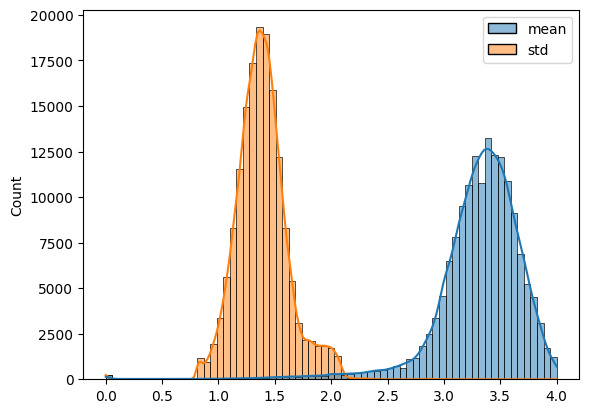

In [29]:
sns.histplot(df_fca_transformed[['mean','std']],kde=True)

The given answers are NOT normally distributed, which can make ML algorithms behave badly. Visualize this

In [30]:
# sns.histplot(df_fca_transformed.iloc[:,5:100],kde=True,legend=False,stat='density')


<Axes: ylabel='Count'>

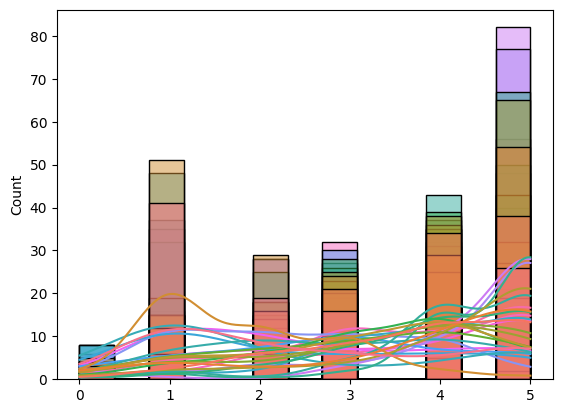

In [31]:
sns.histplot(df_fca_transformed.iloc[:,5:30],kde=True,legend=False)

In [32]:
# sns.histplot(df_fca_transformed.iloc[:,5],kde=True,legend=False)

I don't know how to take this into account, I'll proceed with first scaling the features, check how the graphs look afterwards en experiment with replacing the Nan's

In [33]:
sc = StandardScaler()
scaled_num_feat = pd.DataFrame(sc.fit_transform(df_fca_transformed.iloc[:,4:]),columns=df_fca_transformed.iloc[:,4:].columns, index=df_fca_transformed.index)
scaled_num_feat.head()

,TimeSpentTest,Answer1_117,Answer1_118,Answer1_119,Answer1_120,Answer1_121,Answer1_122,Answer1_123,Answer1_124,Answer1_125,...,Answer3_443,Answer3_444,Answer3_445,Answer3_446,Answer3_447,mean,std,sum,min,max
TestKey,,,,,,,,,,,,,,,,,,,,,
1,-0.793657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-4.231980,1.265162,-3.842031,-1.875016,-5.059862
2,-0.116755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-1.372550,0.285368,-0.738935,0.338697,0.054316
3,-0.207237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.238733,1.463188,-1.928844,-1.875016,0.054316
4,0.266423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.807617,1.045853,-0.435625,0.338697,0.054316
5,0.213984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.068858,0.866828,-0.038989,0.338697,0.054316


In [34]:
print(sc.mean_[-5:],sc.var_[-5:])

[  3.30850058   1.38899699 188.67107318   0.84700061   4.98937938] [1.62983305e-01 5.35752892e-02 1.83701622e+03 2.04059857e-01
 3.82338844e-02]


In [35]:
scaled_num_feat

,TimeSpentTest,Answer1_117,Answer1_118,Answer1_119,Answer1_120,Answer1_121,Answer1_122,Answer1_123,Answer1_124,Answer1_125,...,Answer3_443,Answer3_444,Answer3_445,Answer3_446,Answer3_447,mean,std,sum,min,max
TestKey,,,,,,,,,,,,,,,,,,,,,
1,-0.793657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-4.231980,1.265162,-3.842031,-1.875016,-5.059862
2,-0.116755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-1.372550,0.285368,-0.738935,0.338697,0.054316
3,-0.207237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.238733,1.463188,-1.928844,-1.875016,0.054316
4,0.266423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.807617,1.045853,-0.435625,0.338697,0.054316
5,0.213984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.068858,0.866828,-0.038989,0.338697,0.054316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160063,-0.219233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.950696,-0.649272,-1.042245,0.338697,0.054316
160064,-0.238083,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.238441,0.817412,-1.065577,-1.875016,0.054316
160065,-0.193870,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-1.538227,2.366845,-1.392218,-1.875016,0.054316


I think the best strategy is to impute missing values with the mean of each feature, which is 0 because of the scaling. I use an imputer because this gives the possibility of adding an indicator that shows whether a value has been filled or not. I define the fill_value to override the very small value which should be 0 as the column mean after scaling. The strategy is constant because I know the mean is 0. Notice that there is one less column with indicators because there were no missing values in the TimeSpentTest column, and therefore there was no impution.

In [36]:
imp = SimpleImputer(strategy="constant",fill_value=0,add_indicator=True)
scaled_and_imputed_feat = pd.DataFrame(imp.fit_transform(scaled_num_feat),index=scaled_num_feat.index)
scaled_and_imputed_feat.columns = list(scaled_num_feat.columns) + list([f"Imputed_{i}" for i in range(len(scaled_and_imputed_feat.columns)-len(scaled_num_feat.columns))])
scaled_and_imputed_feat

KeyboardInterrupt: 

Now I need to one hot encode the categorical features (Gender,ChosenGender,ChosenLanguage	and Qualification), after which my data is preprocessed.\
WARNING: all these preprocessing steps were executed on the full dataset, which shouldn't be done. TODO: proceed with this dataset, but when training is finished, I should test a preprocessing pipeline trained on a training set, but to transform a test set.\
NOTE: When a new instance encounters a language not seen during training, it ignores the language

In [ ]:
cat_feat = df_fca_transformed[['Gender','ChosenGender','ChosenLanguage','Qualification']]
enc = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
enc.fit(cat_feat)
cat_feat = enc.transform(cat_feat)
cat_feat = pd.DataFrame(cat_feat,columns=enc.get_feature_names_out(), dtype='int',index=df_fca_transformed.index)
cat_feat

,Gender_Female,Gender_Male,Gender_Unknown,ChosenGender_Female,ChosenGender_Male,ChosenGender_Other,ChosenGender_Unknown,ChosenLanguage_de-BE,ChosenLanguage_de-LU,ChosenLanguage_el-GR,...,ChosenLanguage_nl-BE,Qualification_Bachelor,Qualification_MBA,Qualification_Master,Qualification_PHD,Qualification_PostGraduate,Qualification_Professional,Qualification_Secondary,Qualification_Unknown,Qualification_Vocational
TestKey,,,,,,,,,,,,,,,,,,,,,
1,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,1,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
3,1,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
5,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160063,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
160064,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
160065,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
df_proc = pd.concat([scaled_and_imputed_feat,cat_feat],axis=1)
df_proc

,TimeSpentTest,Answer1_117,Answer1_118,Answer1_119,Answer1_120,Answer1_121,Answer1_122,Answer1_123,Answer1_124,Answer1_125,...,ChosenLanguage_nl-BE,Qualification_Bachelor,Qualification_MBA,Qualification_Master,Qualification_PHD,Qualification_PostGraduate,Qualification_Professional,Qualification_Secondary,Qualification_Unknown,Qualification_Vocational
TestKey,,,,,,,,,,,,,,,,,,,,,
1,-0.793657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
2,-0.116755,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0,0,0,0,1,0
3,-0.207237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,0,0,0,0,0,0
4,0.266423,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
5,0.213984,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160063,-0.219233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
160064,-0.238083,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
160065,-0.193870,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
print(f"Number of different AnsID's: {df_melted.AnswerID.nunique()}")
print(f"Number of different Genders: {df_melted.Gender.nunique()}")
print(f"Number of different ChosenGenders: {df_melted.ChosenGender.nunique()}")
print(f"Number of different ChosenLanguages: {df_melted.ChosenLanguage.nunique()}")
print(f"Number of different Qualifications: {df_melted.Qualification.nunique()}")


Number of different AnsID's: 657
Number of different Genders: 3
Number of different ChosenGenders: 4
Number of different ChosenLanguages: 10
Number of different Qualifications: 9


Now let's do a column count to know what we have done:

- TimeSpentTest: 1
- AnsID: 657 + 657 impute indicators
- Gender: 3
- ChosenGender: 4
- ChosenLanguage: 10
- Qualification: 9
- Aggregations: 5

In [ ]:
1 + 657 * 2 + 3 + 4 + 10 + 9 + 5  

1346

At this point, I should experiment with PCA to lower the amount of dimensions (from 1346 to ?).

In [ ]:
# To bypass getting the data from a database, export the preprocessed dataframe to a csv
# This enables me to use Colab for training

# df_proc.to_csv('../files/csv/df_proc.csv')

**At this point, using a wide dataset does not work well. I proceed with the aggregations I have calculated in df_agg**\
First I scale all columns, then I check for duplicates and NaN's

In [ ]:
sc_agg = StandardScaler()
df_agg_scaled = pd.DataFrame(sc_agg.fit_transform(df_agg),index=df_agg.index,columns=df_agg.columns)
df_agg_scaled.describe()

,TimeSpentTest,mean,std,sum,min,max,ratio_0's,ratio_1's,ratio_2's,ratio_3's,ratio_4's,ratio_5's
count,1.600660e+05,1.600660e+05,1.600660e+05,1.600660e+05,1.600660e+05,1.600660e+05,1.600660e+05,1.600660e+05,1.600660e+05,1.600660e+05,1.600660e+05,1.600660e+05
mean,4.474573e-17,-1.387650e-16,-5.277156e-16,2.848102e-16,-3.551249e-19,2.929780e-17,-2.556899e-17,-1.438256e-16,-2.372234e-16,-1.329943e-16,2.382888e-16,8.354313e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-7.998260e-01,-8.195202e+00,-6.000937e+00,-4.401988e+00,-1.875016e+00,-2.551657e+01,-3.192945e-01,-1.601316e+00,-2.192924e+00,-2.819542e+00,-3.971745e+00,-4.102361e+00
25%,-2.535064e-01,-3.888551e-01,-6.201877e-01,-5.056196e-01,3.386967e-01,5.431573e-02,-3.192945e-01,-7.430893e-01,-6.905087e-01,-6.118086e-01,-5.343918e-01,-4.133503e-01
50%,-9.447732e-02,1.365721e-01,-5.380362e-02,2.176583e-01,3.386967e-01,5.431573e-02,-3.192945e-01,-9.941961e-02,-7.592523e-03,5.051138e-02,1.530789e-01,2.783393e-01
75%,2.078150e-01,5.869383e-01,5.181964e-01,7.542838e-01,3.386967e-01,5.431573e-02,-3.192945e-01,6.345897e-01,6.480070e-01,7.128313e-01,7.780523e-01,7.394657e-01
max,2.880357e+01,1.712854e+00,6.470805e+00,1.757540e+00,4.766122e+00,5.431573e-02,9.959256e+00,3.118929e+00,2.614806e+00,2.037471e+00,2.527978e+00,1.211571e+00


Keep the duplicates for possible later purposes

In [ ]:
df_agg_dedup_sc = df_agg_scaled.drop_duplicates()
df_duplicates = df_agg_scaled[~df_agg_scaled.isin(df_agg_dedup_sc).all(axis=1)]
df_duplicates.describe()

,TimeSpentTest,mean,std,sum,min,max,ratio_0's,ratio_1's,ratio_2's,ratio_3's,ratio_4's,ratio_5's
count,21062.000000,21062.000000,21062.000000,21062.000000,21062.000000,21062.000000,21062.000000,21062.000000,21062.000000,21062.000000,21062.000000,21062.000000
mean,0.093102,0.082120,-0.134058,0.589114,0.244208,-0.100843,-0.203046,0.154180,0.179829,-0.106839,-0.011090,0.066999
std,0.814707,0.892014,0.845500,0.689144,0.677836,1.945433,0.854907,0.977073,0.885528,0.961813,0.901473,0.941477
min,-0.799826,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,-0.319294,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
25%,-0.137662,-0.276264,-0.548448,0.404311,0.338697,0.054316,-0.319294,-0.528533,-0.444659,-0.611809,-0.471894,-0.413350
50%,0.098825,0.136572,-0.079097,0.707621,0.338697,0.054316,-0.319294,0.115137,0.210941,0.050511,0.028084,0.278339
75%,0.293156,0.549408,0.353638,0.964268,0.338697,0.054316,-0.319294,0.758807,0.866540,0.492058,0.528063,0.739466
max,28.376178,1.712854,6.470805,1.757540,4.766122,0.054316,9.959256,3.118929,2.614806,2.037471,2.527978,1.211571


In [ ]:
df_agg_dedup_sc.columns = df_agg_scaled.columns
df_agg_dedup_sc

,TimeSpentTest,mean,std,sum,min,max,ratio_0's,ratio_1's,ratio_2's,ratio_3's,ratio_4's,ratio_5's
TestKey,,,,,,,,,,,,
1,-0.793657,-4.231980,1.265162,-3.842031,-1.875016,-5.059862,4.477363,-1.601316,0.691714,-0.876737,-0.671886,-4.102361
2,-0.116755,-1.372550,0.285368,-0.738935,0.338697,0.054316,-0.319294,1.876759,1.855690,-1.030116,-1.077132,-1.432682
3,-0.207237,-0.238733,1.463188,-1.928844,-1.875016,0.054316,1.238062,-1.172202,-0.881725,-0.170262,0.528063,0.047776
4,0.266423,-0.807617,1.045853,-0.435625,0.338697,0.054316,-0.319294,2.870495,-1.433809,1.270574,-3.392823,0.703061
5,0.213984,-0.068858,0.866828,-0.038989,0.338697,0.054316,-0.319294,1.628325,-0.421655,-1.030116,-0.787670,0.970029
...,...,...,...,...,...,...,...,...,...,...,...,...
160063,-0.219233,0.950696,-0.649272,-1.042245,0.338697,0.054316,-0.319294,-0.148933,-1.823099,0.916622,1.104961,0.579845
160064,-0.238083,0.238441,0.817412,-1.065577,-1.875016,0.054316,0.414888,-0.589835,-0.132469,-1.084894,0.742340,0.607715
160065,-0.193870,-1.538227,2.366845,-1.392218,-1.875016,0.054316,2.250343,-0.421254,-1.291475,-0.391035,-0.534392,-0.615093


In [ ]:
# df_agg_dedup_sc.to_csv('../csv/df_agg_dedup_sc.csv')

### Split dataset

In [37]:
# This cell enables me to not execute all the former cells
# df_proc = pd.read_csv('../files/csv/df_proc.csv',index_col = 'FCATestKey')
# df_proc

df_agg_dedup_sc = pd.read_csv('../../../files/csv/df_agg_dedup_sc.csv',index_col = 'FCATestKey')
df_agg_dedup_sc

,TimeSpentTest,mean,std,sum,min,max,ratio_0's,ratio_1's,ratio_2's,ratio_3's,ratio_4's,ratio_5's
FCATestKey,,,,,,,,,,,,
1,-0.793657,-4.231980,1.265162,-3.842031,-1.875016,-5.059862,4.477363,-1.601316,0.691714,-0.876737,-0.671886,-4.102361
2,-0.116755,-1.372550,0.285368,-0.738935,0.338697,0.054316,-0.319294,1.876759,1.855690,-1.030116,-1.077132,-1.432682
3,-0.207237,-0.238733,1.463188,-1.928844,-1.875016,0.054316,1.238062,-1.172202,-0.881725,-0.170262,0.528063,0.047776
4,0.266423,-0.807617,1.045853,-0.435625,0.338697,0.054316,-0.319294,2.870495,-1.433809,1.270574,-3.392823,0.703061
5,0.213984,-0.068858,0.866828,-0.038989,0.338697,0.054316,-0.319294,1.628325,-0.421655,-1.030116,-0.787670,0.970029
...,...,...,...,...,...,...,...,...,...,...,...,...
160063,-0.219233,0.950696,-0.649272,-1.042245,0.338697,0.054316,-0.319294,-0.148933,-1.823099,0.916622,1.104961,0.579845
160064,-0.238083,0.238441,0.817412,-1.065577,-1.875016,0.054316,0.414888,-0.589835,-0.132469,-1.084894,0.742340,0.607715
160065,-0.193870,-1.538227,2.366845,-1.392218,-1.875016,0.054316,2.250343,-0.421254,-1.291475,-0.391035,-0.534392,-0.615093


In [ ]:
# from sklearn.model_selection import train_test_split

# df_processed_train_full, df_processed_test = train_test_split(df_proc)
# df_processed_train = df_processed_train_full[:-10000] 
# df_processed_valid = df_processed_train_full[-10000:] 
# print(len(df_processed_train),len(df_processed_valid),len(df_processed_test))

At this stage, it might be helpful to visualize the instances, therefore I need to bring the number of dimensions down to 2.

In [38]:
from sklearn.decomposition import PCA

df_for_pca = df_agg_dedup_sc
pca = PCA(n_components=2)
km_in_train_pca = pd.DataFrame(pca.fit_transform(df_for_pca), index=df_for_pca.index,columns=['x','y'])
km_in_train_pca


,x,y
FCATestKey,,
1,7.323288,5.234040
2,1.753408,-1.435529
3,2.149357,1.634873
4,1.786520,-2.518989
5,0.664317,-2.274031
...,...,...
160063,-1.329568,1.020164
160064,1.164033,0.355226
160065,4.008877,1.113210


<Axes: xlabel='x', ylabel='y'>

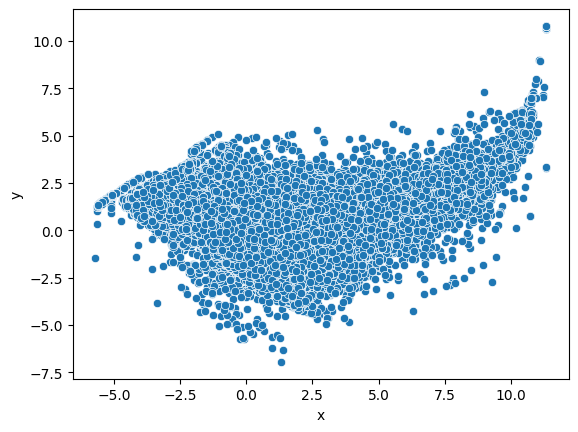

In [39]:
sns.scatterplot(km_in_train_pca,x=km_in_train_pca.x,y=km_in_train_pca.y)

### Model Selection

#### KMeans

In [40]:
# Copy the dataframe before each model to make sure we start from the same base every time we try out a model
# df_km_train = df_processed_train_full
# df_km_valid = df_processed_valid
# df_km_test = df_processed_test

Hold on, why would we need to split the dataset for clustering? Since there are no labels, we cannot do performance checks on training data.
The first training run was unsuccesful. Without PCA, it took too long to train, and the silhouette score dropped when n_clusters>2\
This is the best dataset I can get for use with KMeans. Since plotting the instances in 2D results in one large blob with some outliers, I don't expect for KMeans to work properly, not even with a low amount of clusters. The silhouette score for 2 clusters is 0.387.

In [41]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.model_selection import ParameterGrid
from sklearn import metrics

# df_km = df_proc
# df_km = km_in_train_pca
df_km = df_agg_dedup_sc

# n_clusters = [2, 3]
n_clusters = [2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40]
parameter_grid = ParameterGrid({'n_clusters': n_clusters})
best_score = -1
# Use Elkan to speed things up, but might not work well if clusters are not separated well
# kmeans_model = KMeans(algorithm="elkan")
# Use MiniBatchKmeans to speed things up some more since we've not used PCA yet. Small reduction of quality is possible
kmeans_model = MiniBatchKMeans()

silhouette_scores = []

# grid searching returns an "ideal" amount of clusters of 2
# for p in parameter_grid:
#     kmeans_model.set_params(**p)
#     kmeans_model.fit(df_km)
#     ss = metrics.silhouette_score(df_km, kmeans_model.labels_)
#     silhouette_scores += [ss]
#     print('Parameter:', p, 'Score', ss)

#     if ss > best_score:
#         best_score = ss
#         best_grid = p

In [42]:
# km_1, km_2 = KMeans(1), KMeans(2)
# km_1.fit(df_km)
# km_2.fit(df_km)
# # print("Silhouette score 1 cluster: " +metrics.silhouette_score(df_km,km_1.labels_))
# print("Silhouette score 2 clusters: " +metrics.silhouette_score(df_km,km_2.labels_))
# print("Inertia 1 cluster: " +km_1.inertia_)
# print("Inertia 2 clusters: " +km_2.inertia_)

Create a Voronoi diagram

In [43]:
# def save_fig(image_path, fig_id, tight_layout=True, fig_extension="png", resolution=300):
#     path = image_path / f"{fig_id}.{fig_extension}"
#     if tight_layout:
#         plt.tight_layout()
#     plt.savefig(path, format=fig_extension, dpi=resolution)

# def plot_data(X):
#     plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

# def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
#     if weights is not None:
#         centroids = centroids[weights > weights.max() / 10]
#     plt.scatter(centroids[:, 0], centroids[:, 1],
#                 marker='o', s=35, linewidths=8,
#                 color=circle_color, zorder=10, alpha=0.9)
#     plt.scatter(centroids[:, 0], centroids[:, 1],
#                 marker='x', s=2, linewidths=12,
#                 color=cross_color, zorder=11, alpha=1)

# def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
#                              show_xlabels=True, show_ylabels=True):
#     mins = X.min(axis=0) - 0.1
#     maxs = X.max(axis=0) + 0.1
#     xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
#                          np.linspace(mins[1], maxs[1], resolution))
#     Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
#     Z = Z.reshape(xx.shape)

#     plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
#                 cmap="Pastel2")
#     plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
#                 linewidths=1, colors='k')
#     plot_data(X)
#     if show_centroids:
#         plot_centroids(clusterer.cluster_centers_)

#     if show_xlabels:
#         plt.xlabel("$x_1$")
#     else:
#         plt.tick_params(labelbottom=False)
#     if show_ylabels:
#         plt.ylabel("$x_2$", rotation=0)
#     else:
#         plt.tick_params(labelleft=False)

In [44]:
# plt.figure(figsize=(8, 4))
# plot_decision_boundaries(kmeans_model, df_km)
# save_fig("../files/img/model_figs","voronoi_plot_km")
# plt.show()

Plot the silhouette scores to see which amount of clusters works best

In [45]:
# plt.bar(range(len(silhouette_scores)), list(silhouette_scores), align='center', color='#722f59', width=0.5)
# plt.xticks(range(len(silhouette_scores)), list(n_clusters))
# plt.title('Silhouette Score', fontweight='bold')
# plt.xlabel('Number of Clusters')
# plt.show()

#### DBScan

DBScan clusters around chosen centroids. Whenever a new instance lies within a dinstance e from a core instance, it belongs to the cluster. If not, it belongs to a new cluster. The number of clusters is not a parameter, the model looks for this number itself. The lower e, the more clusters. This model only works if the clusters are separated by areas of low density. DBSCAN scales bad to big datasets (O(m²n)), I don't know if 160.000 samples is big or not. Using this model on a dataset of items (instead of tests), this probably won't work.

In [46]:
df_dbscan = df_agg_dedup_sc

In [47]:
from sklearn.cluster import DBSCAN

# Again, I assume separating a test set us


# dbscan = DBSCAN(eps=0.05, min_samples=5,n_jobs=-1)
# dbscan.fit(df_dbscan)

When using DBScan with default settings (e=0.05), I get 14178 instances that are not in the "-1" cluster. To filter these instances out, add the given labels and filter the rows with a label > -1. \
Terminology:
- Core instance = an instance that has at least min_samples in its neighbourhood
- Cluster instance = any instance that is found within eps of a core instance
- Anomaly = any instance that is not part of a cluster

There are more cluster instances than core instances! most of them are cores, but a small portion at the edges of clusters are not in dbscan.components. Note: 

In [48]:
# How many instances are assigned to clusters != -1
values, counts = np.unique(dbscan.labels_,return_counts=True)
counts[1:].sum()

NameError: name 'dbscan' is not defined

In [ ]:
df_agg_dedup_sc.index

Index([     1,      2,      3,      4,      5,      6,      7,      8,      9,
           10,
       ...
       160058, 160059, 160060, 160061, 160062, 160063, 160064, 160065, 160066,
       160067],
      dtype='int64', name='TestKey', length=139004)

In [53]:
# labels = pd.DataFrame(dbscan.labels_,index=df_agg_dedup_sc.index, columns=['label'])
labels = pd.DataFrame(loaded_model.labels_,index=df_agg_dedup_sc.index, columns=['label'])

In [54]:
labels

,label
FCATestKey,
1,-1
2,0
3,1
4,0
5,0
...,...
160063,0
160064,1
160065,1


In [ ]:
labels[labels.label>-1]

,label
TestKey,
52,1115
61,0
80,1
81,1
82,1
...,...
160047,508
160049,366
160052,856


In [ ]:
dbscan_anom = pd.concat([df_dbscan,labels],axis=1)
dbscan_anom = dbscan_anom[dbscan_anom.label!=-1]


I have already transformed this dataset into a 2D-dataset for plotting, let's use these instances, filtered on the instances above and see where they are located in a 2D grid

In [ ]:
dbscan_anom

,TimeSpentTest,mean,std,sum,min,max,ratio_0's,ratio_1's,ratio_2's,ratio_3's,ratio_4's,ratio_5's,label
TestKey,,,,,,,,,,,,,
52,0.297612,0.174103,-0.045031,0.800947,0.338697,0.054316,-0.319294,-0.099420,0.866540,-0.391035,-0.221905,0.278339,1115
61,-0.234999,0.990391,-0.807474,-0.248973,0.338697,0.054316,-0.319294,-0.716270,-0.690509,0.216091,1.184285,0.653004,0
80,-0.794342,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361,1
81,-0.798798,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361,1
82,-0.796741,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
160047,-0.234656,0.680765,0.032636,-0.388962,-1.875016,0.054316,0.323115,-1.306300,-0.990992,0.823218,0.496814,0.653004,508
160049,-0.380661,1.196809,-0.807474,-0.155646,0.338697,0.054316,-0.319294,-0.421254,-1.591958,0.216091,1.528020,0.970029,366
160052,-0.257276,0.990391,-0.962731,-0.248973,0.338697,0.054316,-0.319294,-0.716270,-0.990992,0.519655,1.528020,0.335980,856


In [ ]:
# Use the 2D coordinates transformed before
scaled_df = km_in_train_pca
anomalies_2d = scaled_df.loc[dbscan_anom.index]


In [ ]:
anomalies_2d

,x,y
TestKey,,
52,-0.607959,-0.865094
61,-1.670126,0.724483
80,11.334017,10.794918
81,11.334036,10.795549
82,11.334028,10.795258
...,...,...
160047,-0.070531,1.441605
160049,-1.885224,0.642343
160052,-1.843915,1.135634


<Axes: xlabel='x', ylabel='y'>

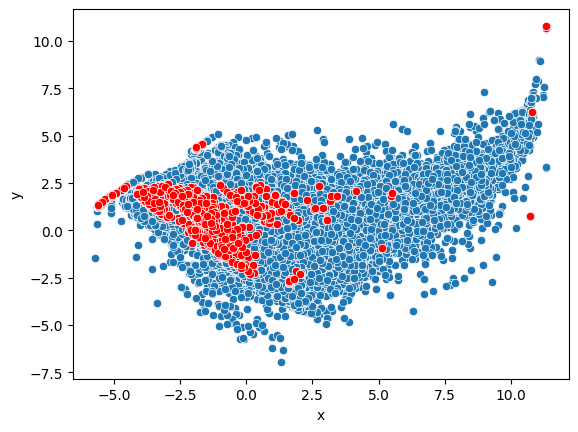

In [ ]:
sns.scatterplot(km_in_train_pca,x=km_in_train_pca.x,y=km_in_train_pca.y)
sns.scatterplot(anomalies_2d,x=anomalies_2d.x,y=anomalies_2d.y,color="red")


Add the core instances to this visualisation. NOTE: I have marked the anomalies by gathering the instances labeled as > -1 (which should be the opposite)

In [ ]:
pd.DataFrame(dbscan.components_)

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.234999,0.990391,-0.807474,-0.248973,0.338697,0.054316,-0.319294,-0.716270,-0.690509,0.216091,1.184285,0.653004
1,-0.794342,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
2,-0.798798,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
3,-0.796741,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
4,-0.789544,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
...,...,...,...,...,...,...,...,...,...,...,...,...
11964,-0.248365,0.422742,-0.295084,-0.505620,0.338697,0.054316,-0.319294,-0.126239,-0.089542,-0.087472,0.840550,0.018956
11965,-0.234656,0.680765,0.032636,-0.388962,-1.875016,0.054316,0.323115,-1.306300,-0.990992,0.823218,0.496814,0.653004
11966,-0.257276,0.990391,-0.962731,-0.248973,0.338697,0.054316,-0.319294,-0.716270,-0.990992,0.519655,1.528020,0.335980
11967,-0.366609,1.145205,-0.940610,-0.178978,0.338697,0.054316,-0.319294,-1.011285,-0.390026,-0.087472,1.184285,0.970029


In [ ]:
pd.DataFrame(dbscan.core_sample_indices_)

,0
0,60
1,79
2,80
3,81
4,88
...,...
11964,138978
11965,138983
11966,138988
11967,138993


In [ ]:
pd.DataFrame(dbscan.components_,index=(dbscan.core_sample_indices_+1),columns=df_agg_dedup_sc.columns).head()

,TimeSpentTest,mean,std,sum,min,max,ratio_0's,ratio_1's,ratio_2's,ratio_3's,ratio_4's,ratio_5's
61,-0.234999,0.990391,-0.807474,-0.248973,0.338697,0.054316,-0.319294,-0.716270,-0.690509,0.216091,1.184285,0.653004
80,-0.794342,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
81,-0.798798,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
82,-0.796741,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
89,-0.789544,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361


Somehow, when inspecting the dbscan_components (core instances), the indexes do not match. When I manually add 1 to the index of the core_samples, the indexes op the components match again with the base dataframe (df_agg_dedup_sc). 

In [ ]:
len(dbscan.core_sample_indices_)
core_samples = pd.DataFrame(dbscan.components_,index=dbscan.core_sample_indices_+1,columns=df_agg_dedup_sc.columns)

# core_samples = pd.merge(core_samples,labels,how='left', left_index=True)
core_samples

,TimeSpentTest,mean,std,sum,min,max,ratio_0's,ratio_1's,ratio_2's,ratio_3's,ratio_4's,ratio_5's
61,-0.234999,0.990391,-0.807474,-0.248973,0.338697,0.054316,-0.319294,-0.716270,-0.690509,0.216091,1.184285,0.653004
80,-0.794342,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
81,-0.798798,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
82,-0.796741,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
89,-0.789544,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
...,...,...,...,...,...,...,...,...,...,...,...,...
138979,-0.248365,0.422742,-0.295084,-0.505620,0.338697,0.054316,-0.319294,-0.126239,-0.089542,-0.087472,0.840550,0.018956
138984,-0.234656,0.680765,0.032636,-0.388962,-1.875016,0.054316,0.323115,-1.306300,-0.990992,0.823218,0.496814,0.653004
138989,-0.257276,0.990391,-0.962731,-0.248973,0.338697,0.054316,-0.319294,-0.716270,-0.990992,0.519655,1.528020,0.335980
138994,-0.366609,1.145205,-0.940610,-0.178978,0.338697,0.054316,-0.319294,-1.011285,-0.390026,-0.087472,1.184285,0.970029


In [ ]:
core_samples[~core_samples.isin(anomalies_2d)]


,TimeSpentTest,mean,std,sum,min,max,ratio_0's,ratio_1's,ratio_2's,ratio_3's,ratio_4's,ratio_5's
61,-0.234999,0.990391,-0.807474,-0.248973,0.338697,0.054316,-0.319294,-0.716270,-0.690509,0.216091,1.184285,0.653004
80,-0.794342,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
81,-0.798798,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
82,-0.796741,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
89,-0.789544,-8.195202,-6.000937,-4.401988,-1.875016,-25.516571,9.959256,-1.601316,-2.192924,-2.819542,-3.971745,-4.102361
...,...,...,...,...,...,...,...,...,...,...,...,...
138979,-0.248365,0.422742,-0.295084,-0.505620,0.338697,0.054316,-0.319294,-0.126239,-0.089542,-0.087472,0.840550,0.018956
138984,-0.234656,0.680765,0.032636,-0.388962,-1.875016,0.054316,0.323115,-1.306300,-0.990992,0.823218,0.496814,0.653004
138989,-0.257276,0.990391,-0.962731,-0.248973,0.338697,0.054316,-0.319294,-0.716270,-0.990992,0.519655,1.528020,0.335980
138994,-0.366609,1.145205,-0.940610,-0.178978,0.338697,0.054316,-0.319294,-1.011285,-0.390026,-0.087472,1.184285,0.970029


In [ ]:
labels.iloc[60]

label    0
Name: 61, dtype: int64

<Axes: xlabel='x', ylabel='y'>

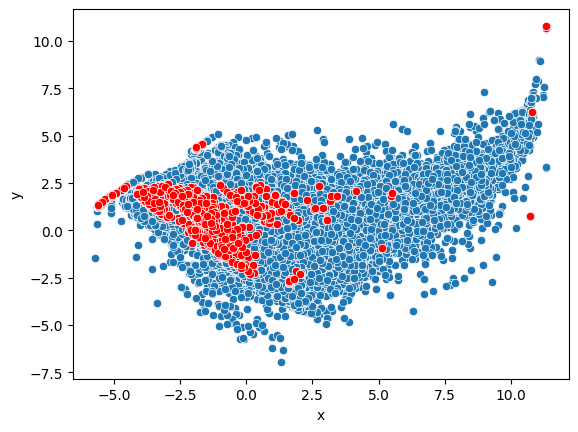

In [ ]:
sns.scatterplot(km_in_train_pca,x=km_in_train_pca.x,y=km_in_train_pca.y)
sns.scatterplot(anomalies_2d,x=anomalies_2d.x,y=anomalies_2d.y,color="red")
# sns.scatterplot(core_samples,x=anomalies_2d.loc[core_samples.index].x,y=anomalies_2d.loc[core_samples.index].y,color="green")


NOTE: Usually, DBScan labels the instances that don't lie within a cluster as -1. In the example above, the red instances are those with a label that is NOT equal to -1. What is happening? 

In [ ]:
from pandas import Timedelta
from sklearn import metrics

def GridSearchDBScan(min_samples_values,eps_values):
  min_samples_values = min_samples_values
  eps_values = eps_values
  results = []
  for min_samples in min_samples_values:
      for eps in eps_values:
        try:   
            startTime = datetime.now() 
            print(f"Trying min_samples {min_samples} and eps {eps}")
            # Create and fit DBSCAN model
            dbscan = DBSCAN(min_samples=min_samples, eps=eps)
            dbscan.fit(df_dbscan)
            labels = dbscan.labels_

            if len(set(labels)) > 1:
                silhouette_avg = metrics.silhouette_score(df_dbscan, labels)
            else:
                silhouette_avg = -1
            
            duration = Timedelta(datetime.now()-startTime)
            print(f"Silhouette ({min_samples,eps}): {silhouette_avg}")
            print(f"Duration: {duration}")
            results.append({
                'min_samples': min_samples,
                'eps': eps,
                'silhouette_score': silhouette_avg,
                'num_clusters': len(set(labels)) - (1 if -1 in labels else 0),
                'num_noise': list(labels).count(-1)
            })
        except Exception as error:
           print(error)
  return results

# results = GridSearchDBScan(min_samples_values=[3, 5, 10, 20, 50],eps_values=[0.01,0.05,0.5,2,5])

# results = GridSearchDBScan(min_samples_values=[5, 10, 20, 50],eps_values=[0.01,0.05,0.5,2,5])

output_so_far = '''
Trying min_samples 3 and eps 0.01
Silhouette ((3, 0.01)): -0.6458220355212104
Duration: 0 days 00:04:12.465108
Trying min_samples 3 and eps 0.05
Silhouette ((3, 0.05)): -0.47942593254972715
Duration: 0 days 00:04:14.771110
Trying min_samples 3 and eps 0.5
Silhouette ((3, 0.5)): -0.5165430791873135
Duration: 0 days 00:06:04.409761
Trying min_samples 3 and eps 2
Silhouette ((3, 2)): 0.22729834613483366
Duration: 0 days 00:21:46.921283
'''

In [ ]:
startTime = datetime.now() 

dbscan = DBSCAN(min_samples=3, eps=5)
dbscan.fit(df_dbscan)
labels = dbscan.labels_
if len(set(labels)) > 1:
    silhouette_avg = metrics.silhouette_score(df_dbscan, labels)
else:
    silhouette_avg = -1            

duration = Timedelta(datetime.now()-startTime)
print(f"Silhouette ({3,5}): {silhouette_avg}")
print(f"Duration: {duration}")

This use of DBSCAN is not perfect: 9% of the instances are allocated to a cluster, but some instances that appear to be outliers (like the instances in the upper right corner) are actually in a cluster. I should fiddle around with my hyperparameters. Enlarging eps will make more instances fall in a cluster since there is a larger tolerance. Enlarging min_samples will make the amount of core instances smaller and raise the number of anomalies, but it won't fix the fact that the upper right instances are in a cluster, unless the number of instances in that area are smaller than min_samples.

In [ ]:
# sns.scatterplot(km_in_train_pca,x=km_in_train_pca.x,y=km_in_train_pca.y)
# sns.scatterplot(anomalies_2d,x=anomalies_2d.x,y=anomalies_2d.y,color="red")
# plt.xlim(11.25,11.50)
# plt.ylim(10.50,11)
# plt.show()

In [ ]:
# dbscan2 = DBSCAN(eps=0.05, min_samples=10,n_jobs=-1)
# dbscan2.fit(df_dbscan)
# labels2 = pd.DataFrame(dbscan2.labels_,index=df_agg_dedup_sc.index, columns=['label'])
# dbscan2_anom = pd.concat([df_dbscan,labels2],axis=1)
# dbscan2_anom = dbscan_anom[dbscan2_anom.label!=-1] # The anomalies should be those labeled as -1, not the opposite!
# anomalies2_2d = scaled_df.loc[dbscan2_anom.index]
# sns.scatterplot(km_in_train_pca,x=km_in_train_pca.x,y=km_in_train_pca.y)
# sns.scatterplot(anomalies2_2d,x=anomalies2_2d.x,y=anomalies2_2d.y,color="red")

In [ ]:
# sns.scatterplot(km_in_train_pca,x=km_in_train_pca.x,y=km_in_train_pca.y)
# sns.scatterplot(anomalies2_2d,x=anomalies2_2d.x,y=anomalies2_2d.y,color="red")
# plt.xlim(11.25,11.50)
# plt.ylim(10.50,11)
# plt.show()

In [ ]:
# dbscan3 = DBSCAN(eps=0.05, min_samples=20,n_jobs=-1)
# dbscan3.fit(df_dbscan)
# labels3 = pd.DataFrame(dbscan3.labels_,index=df_agg_dedup_sc.index, columns=['label'])
# dbscan3_anom = pd.concat([df_dbscan,labels3],axis=1)
# dbscan3_anom = dbscan_anom[dbscan3_anom.label!=-1] # The anomalies should be those labeled as -1, not the opposite!
# anomalies3_2d = scaled_df.loc[dbscan3_anom.index]
# sns.scatterplot(km_in_train_pca,x=km_in_train_pca.x,y=km_in_train_pca.y)
# sns.scatterplot(anomalies3_2d,x=anomalies3_2d.x,y=anomalies3_2d.y,color="red")

In [ ]:
scaled_df = km_in_train_pca


In [ ]:
# dbscan4 = DBSCAN(eps=2, min_samples=20,n_jobs=-1)
# dbscan4.fit(df_dbscan)
# labels4 = pd.DataFrame(dbscan4.labels_,index=df_agg_dedup_sc.index, columns=['label'])
# dbscan4_anom = pd.concat([df_dbscan,labels4],axis=1)
# dbscan4_anom = dbscan4_anom[dbscan4_anom.label==-1] # The anomalies should be those labeled as -1, not the opposite!
# anomalies4_2d = scaled_df.loc[dbscan4_anom.index]
# sns.scatterplot(km_in_train_pca,x=km_in_train_pca.x,y=km_in_train_pca.y)
# sns.scatterplot(anomalies4_2d,x=anomalies4_2d.x,y=anomalies4_2d.y,color="yellow")

This last model moves in the right direction, there seem to be way less instances labeled as -1 (which are the yellow dots). I try again by increasing min_samples to 50 and I hope my laptop doesn't explode

In [ ]:
from sklearn.cluster import DBSCAN
scaled_df = km_in_train_pca


<Axes: xlabel='x', ylabel='y'>

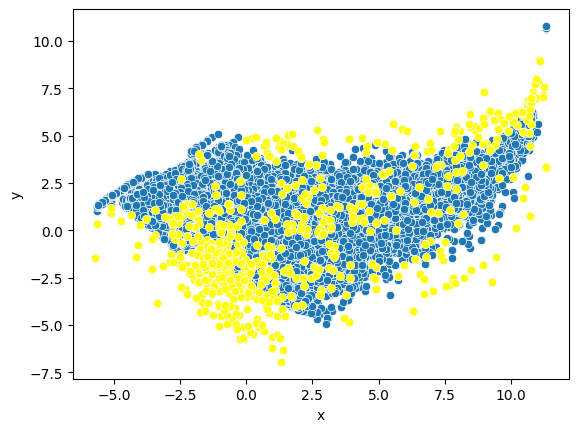

In [ ]:
# dbscan5 = DBSCAN(eps=2, min_samples=50,n_jobs=-1)
dbscan5 = loaded_model
# dbscan5.fit(df_dbscan)
labels5 = pd.DataFrame(dbscan5.labels_,index=df_agg_dedup_sc.index, columns=['label'])
dbscan5_anom = pd.concat([df_dbscan,labels5],axis=1)
dbscan5_anom = dbscan5_anom[dbscan5_anom.label==-1] # The anomalies should be those labeled as -1, not the opposite!
anomalies5_2d = scaled_df.loc[dbscan5_anom.index]
sns.scatterplot(km_in_train_pca,x=km_in_train_pca.x,y=km_in_train_pca.y)
sns.scatterplot(anomalies5_2d,x=anomalies5_2d.x,y=anomalies5_2d.y,color="yellow")

In [ ]:
# joblib.dump(dbscan5, "../models/dbscan_eps2_ms50.pkl") 


['../models/dbscan_eps2_ms50.pkl']

In [ ]:
# os.getcwd()

'c:\\Users\\Mikel\\DEP2-G2\\anomalies\\FCA\\scripts'

In [50]:

loaded_model = joblib.load(f"../../../models/dbscan_eps2_ms50.pkl")

In [ ]:
silhouette_score_dbscan_eps2_ms50 = sklearn.metrics.silhouette_score(df_dbscan, labels5)
silhouette_score_dbscan_eps2_ms50

c:\Users\Mikel\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
silhouette_score_dbscan_eps2_ms50

0.24944003977192356

In [ ]:
len(anomalies5_2d)

659

In [ ]:
# Filter the original dataframe on the found instances by index (which is the FCATestKey)
df = df_fca_transformed.loc[dbscan5_anom.index][['Gender','ChosenLanguage','Qualification','TimeSpentTest']]
df

,Gender,ChosenLanguage,Qualification,TimeSpentTest
TestKey,,,,
1,Female,en-INT,Unknown,18
21,Female,nl-BE,Bachelor,109
77,Male,en-INT,Unknown,86288
183,Male,en-INT,Unknown,116
198,Female,nl-BE,Unknown,1638
...,...,...,...,...
158283,Female,fr-BE,PostGraduate,89
158370,Female,nl-BE,Bachelor,23722
158372,Female,fr-BE,Unknown,21800


In [ ]:
# os.chdir('..')
# csv_path = os.path.join("csv")
# os.chdir(csv_path)
# df.to_csv("dbscan_anomalies.csv")

In [56]:
labels.rename_axis('TestKey', inplace=True)

In [57]:
labels['is_anomaly'] = labels[['label']].map(lambda label : 1 if label==-1 else 0)
labels.drop(columns=['label'],inplace=True)
os.chdir('..')
csv_path = os.path.join("csv")
os.chdir(csv_path)
labels.to_csv('dbscan_anomalies.csv')

In [ ]:
os.chdir(original_directory)